**Calcular indicadores geoespaciales de minería**

# Setup

In [50]:
# define root path of project 
from pathlib import Path
import sys

ROOT = Path("..").resolve()
sys.path.append(str(ROOT))

# load general setup
from utils.setup_general import *

# load GIS setup
from utils.setup_gis_python import *

# Load utils for SR 2021
from utils.utils_for_SR2021 import *

# Parámetros

In [2]:
# Reproyectar ambas capas a un CRS apropiado para Colombia
# Se va a proyectar en MAGNA-SIRGAS que es el estándar en Colombia
# Definir 
crs_area = "EPSG:3116"

# Definir archivo de salida
El archivo de salida se estructura para conservar la misma estructura entre todas las bases de datos

In [3]:
ORDEN_DF

['codigo_dane_municipio',
 'anno',
 'nombre_variable',
 'variable_sujeto',
 'variable_medicion',
 'variable_detalle',
 'variable_descripcion',
 'valor',
 'clasificacion_econometria']

In [4]:
# Definir DF con la estructura acordada para el proyecto
# La variable global ORDEN_DF ya tiene la lista de todas las columnas ordenadas
# Inicializar el DF vacío
dfOutput_indicadoresGeoespacialesMinerales = pd.DataFrame(
    columns=[ORDEN_DF]
)

# Cargar datos y armonizar sistemas de coordenadas

In [5]:
# rutas de poligonos
ruta_municipios = DATA/"raw/baa_DANE_poligonosMpiosDptos/ADMINISTRATIVO/MGN_ADM_MPIO_GRAFICO.shp"
ruta_departamentos = DATA/"raw/baa_DANE_poligonosMpiosDptos/ADMINISTRATIVO/MGN_ADM_DPTO_POLITICO.shp"
ruta_potencialMineral = DATA/"intermediate/e2011_SGC_ZonasPotencialMineral_armonizado.parquet"
ruta_aluviones = DATA/"intermediate/e2011_SGC_aluviones_armonizado.parquet"
ruta_titulosMineros = DATA/"intermediate/e2011_ANM_poligonosTitulosMineros_armonizado.parquet"


# cargar geo-data-frames
gdf_municipios = gpd.read_file(ruta_municipios)
gdf_departamentos = gpd.read_file(ruta_departamentos)
gdf_potencialMineral = gpd.read_parquet(ruta_potencialMineral)
gdf_aluviones = gpd.read_parquet(ruta_aluviones)


In [6]:
# cargar dataframes
# Los titulos mineros quedaron descargados como dataframes y on como geodataframes
# por eso, hay que cargarlos como dataframes y después convertirlos a geodataframes
# Lo importante acá es reconcoer que los títulos mineros están en crs="EPSG:102100"
df_titulosMineros = pd.read_parquet(ruta_titulosMineros)

# reconstruir geometrias
df_titulosMineros["geometry"] = gpd.GeoSeries.from_wkb(
    df_titulosMineros["geometry"]
)

gdf_titulosMineros = gpd.GeoDataFrame(
    df_titulosMineros,
    geometry="geometry",
    crs="EPSG:3857")
# En la exploración de datos cuando descargaba cada título minero obtenía crs="EPSG:102100"
# Esto es un código de ESRI, no un código EPSG. El equivalente oficial es EPSG:3857
# Ver: https://support.esri.com/en-us/knowledge-base/why-does-arcgis-online-use-a-deprecated-spatial-referen-000013950?utm_source=chatgpt.com

## Armonizar sistemas de coordenadas

In [7]:
# Explorar Coordinate Reference System (CRS)
print(MSC_SEPARADOR + '\nCRS Original')
print('Municipios:', gdf_municipios.crs)
print('Departamentos:', gdf_departamentos.crs)
print('Potencial Mineral:', gdf_potencialMineral.crs)
print('Aluviones', gdf_aluviones.crs)
print('Titulos Mineros', gdf_titulosMineros.crs)

# Reproyectar ambas capas a un CRS apropiado para Colombia
# Se va a proyectar en MAGNA-SIRGAS que es el estándar en Colombia
gdf_municipios = gdf_municipios.to_crs(crs_area)
gdf_departamentos = gdf_departamentos.to_crs(crs_area)
gdf_potencialMineral = gdf_potencialMineral.to_crs(crs_area)
gdf_aluviones = gdf_aluviones.to_crs(crs_area)
gdf_titulosMineros = gdf_titulosMineros.to_crs(crs_area)

# # Mostrar nuevos sistema de coordenadas
# Explorar Coordinate Reference System (CRS)
print(MSC_SEPARADOR + '\nCRS Original')
print('Municipios:', gdf_municipios.crs)
print('Departamentos:', gdf_departamentos.crs)
print('Potencial Mineral:', gdf_potencialMineral.crs)
print('Aluviones', gdf_aluviones.crs)
print('Titulos Mineros', gdf_titulosMineros.crs)


--------------------------------
CRS Original
Municipios: EPSG:4326
Departamentos: EPSG:4326
Potencial Mineral: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "WGS 84 / Pseudo-Mercator", "base_crs": {"name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "La

## Revisar geometrías inválidas

In [8]:
# Revisar geometrías inválidas
print(MSC_SEPARADOR, "\nMunicipios")
print(f"\nVálidas:\n{gdf_municipios.is_valid.value_counts()}")
print(f"\nVacías: {gdf_municipios.is_empty.sum()}")
print(f"Totales: {gdf_municipios.shape[0]}")


print(MSC_SEPARADOR, "\nDepartamentos")
print(f"\nVálidas:\n{gdf_departamentos.is_valid.value_counts()}")
print(f"\nVacías: {gdf_departamentos.is_empty.sum()}")
print(f"Totales: {gdf_departamentos.shape[0]}")


print(MSC_SEPARADOR, "\nPotencial Mineral")
print(f"\nVálidas:\n{gdf_potencialMineral.is_valid.value_counts()}")
print(f"\nVacías: {gdf_potencialMineral.is_empty.sum()}")
print(f"Totales: {gdf_potencialMineral.shape[0]}")


print(MSC_SEPARADOR, "\nAluviones")
print(f"\nVálidas:\n{gdf_aluviones.is_valid.value_counts()}")
print(f"\nVacías: {gdf_aluviones.is_empty.sum()}")
print(f"Totales: {gdf_aluviones.shape[0]}")


print(MSC_SEPARADOR, "\nTitulos Mineros")
print(f"\nVálidas:\n{gdf_titulosMineros.is_valid.value_counts()}")
print(f"\nVacías: {gdf_titulosMineros.is_empty.sum()}")
print(f"Totales: {gdf_titulosMineros.shape[0]}")



-------------------------------- 
Municipios

Válidas:
True    1122
Name: count, dtype: int64

Vacías: 0
Totales: 1122

-------------------------------- 
Departamentos

Válidas:
True    33
Name: count, dtype: int64

Vacías: 0
Totales: 33

-------------------------------- 
Potencial Mineral

Válidas:
True    728
Name: count, dtype: int64

Vacías: 0
Totales: 728

-------------------------------- 
Aluviones

Válidas:
True    31
Name: count, dtype: int64

Vacías: 0
Totales: 31

-------------------------------- 
Titulos Mineros

Válidas:
True     2763
False       9
Name: count, dtype: int64

Vacías: 0
Totales: 2772


## Corregir geometrías inválidas

In [9]:
mask = ~gdf_titulosMineros.is_valid # Identificar la fila de geometría inválida
# Corregir el polígono
gdf_titulosMineros.loc[mask, "geometry"] = gdf_titulosMineros.loc[mask, "geometry"].apply(make_valid)

# Convertir el multipolygon que sale de make_valid en múltiples filas. Necesario para el cálculo de areas
gdf_titulosMineros = gdf_titulosMineros.explode(index_parts=False)

# Las geometrías inválidas eran poligonos que se cortaban entre si.
# Lo que hice fue reexpresarlos de tal forma que no se corten. Por eso, 
# pueden salir exportados como multipolygon. Para el cálculo de áreas necesito
# que sean un solo polígono. Eso es lo que hace ".explode"

In [10]:
# Validar nuevas geometrías
print(MSC_SEPARADOR, "\nTitulos Mineros")
print(f"\nVálidas:\n{gdf_titulosMineros.is_valid.value_counts()}")
print(f"\nVacías: {gdf_titulosMineros.is_empty.sum()}")
print(f"Totales: {gdf_titulosMineros.shape[0]}")



-------------------------------- 
Titulos Mineros

Válidas:
True    2824
Name: count, dtype: int64

Vacías: 0
Totales: 2824


# Consideraciones

## Estimar distancia al potencial mineral
- Pensando que los bordes de los polígonos de potencial minerla no son barreras nítidas (como todo en geología) y que el mineral (o el oro) no solo se da _in situ_ donde hay un yacimiento sino que también se da en el aluvión, conviene considerar un instrumento basado en distancia al potencial mineral (puede ser el polígono de potencial o el aluvión)
- La idea se refuerza al considerar que el mercado laboral del municipio X no se ve afectado únicamente por las producción minera de su propio municipio sino por la producción minera cercana i.e. si hay explotación minera suficientemente cerca y asumiendo bajas barreras al empleo entre municipios, la presencia de una mina cercana podría capturar parte de la oferta laboral del municipio

## Objetivo
- Calcular Instrumentos al potencial de oro
- Area y relacionados para polígonos de potencial mineral
- Distancia al oro para polígonos de potencial mineral y para aluviones


## Resumen

|Potencial mineral|Área|Distancia|
|------|------|------|
|Formación geológica | Minería de veta en el municipio     |Minería de veta cercana     |
|Aluvión     |No se puede calcular porque el aluvión solo es una línea     | Minería de aluvión cercana     |



# Cálculos de Área
## Zonas de potencial mineral
Calculo el área y el porcentaje de área de cada municipio que está dentro de los polígonos de potencial de cada mineral

In [11]:
# Mostrar información de los datos disponibles
print(MSC_SEPARADOR+"Zonas de potencial mineral")
display(gdf_potencialMineral.info())


--------------------------------Zonas de potencial mineral
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 728 entries, 0 to 163
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   FID                   608 non-null    float64 
 1   OBJECTID              608 non-null    float64 
 2   IDZPI                 728 non-null    object  
 3   NOMBRE                728 non-null    object  
 4   GR_MINERAL            728 non-null    object  
 5   SUBGRUPO_M            559 non-null    object  
 6   ELEM_PRINC            728 non-null    object  
 7   ANOMALIAS             544 non-null    object  
 8   DESC_TEMAT            544 non-null    object  
 9   DESC_GEOGR            544 non-null    object  
 10  NUM_ANOM              728 non-null    object  
 11  POTENCIAL             728 non-null    object  
 12  T_MINERIA             491 non-null    object  
 13  RESTRICCIO            461 non-null    object  


None

### Intersección de polígonos

In [12]:
# Extraer información de interés
municipios_base = gdf_municipios[['mpio_cdpmp', 'mpio_cnmbr', 'geometry']]
potencial_base = gdf_potencialMineral[['geometry', 'categoria_armonizada', 'FID']].copy()

# Hacer intersección de polígonos
gdf_interseccion_potencialMpio = gpd.overlay(potencial_base, municipios_base, how='intersection')

In [13]:
# Explorar el resultado
print(MSC_SEPARADOR + '\nShape: ', gdf_interseccion_potencialMpio.shape)

print(MSC_SEPARADOR + '\nHead:\n')
print(gdf_interseccion_potencialMpio.head())

print(MSC_SEPARADOR + '\nInfo:\n')
print(gdf_interseccion_potencialMpio.info())

print(MSC_SEPARADOR + '\nCada poligono de potencial puede quedar dividido en varios municipios:\n')
display(gdf_interseccion_potencialMpio.groupby('FID')['mpio_cnmbr'].count().sort_values(ascending=False))


--------------------------------
Shape:  (3735, 5)

--------------------------------
Head:

     categoria_armonizada   FID mpio_cdpmp mpio_cnmbr                                           geometry
0                     Oro  1.00      54051  ARBOLEDAS  POLYGON ((1126340.17 1323778.977, 1128464.825 ...
1                   Cobre   NaN      54051  ARBOLEDAS  POLYGON ((1120651.505 1327286.995, 1120653.647...
2            Metales base 12.00      54051  ARBOLEDAS  POLYGON ((1123050.632 1324041.608, 1123084.42 ...
3  Minerales industriales 25.00      54051  ARBOLEDAS  POLYGON ((1143004.214 1338750.607, 1144191.499...
4                   Otros  7.00      54051  ARBOLEDAS  POLYGON ((1139345.583 1335982.408, 1139590.106...

--------------------------------
Info:

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3735 entries, 0 to 3734
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   categoria_arm

FID
33.00     72
62.00     65
128.00    63
30.00     60
22.00     56
          ..
147.00     1
131.00     1
158.00     1
125.00     1
117.00     1
Name: mpio_cnmbr, Length: 164, dtype: int64

In [14]:
# Calcular area de cada polígono de intersección generado
# Como ya estoy en Bogotá-Magnas-Sirgas, los cálculos de area ya salen en m^2
gdf_interseccion_potencialMpio["area_intersectada_m2"] = gdf_interseccion_potencialMpio.geometry.area

# En la base de datos de municipios, calcular el area de cada municipio
municipios_base["area_municipio_m2"] = municipios_base.geometry.area

# Agregar cálculo de area municipal al gdf de intersección
gdf_interseccion_potencialMpio = gdf_interseccion_potencialMpio.merge(
    municipios_base[["mpio_cdpmp", "area_municipio_m2"]],
    on="mpio_cdpmp",
    how="left"
)

C:\Users\jcalf\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [15]:
gdf_interseccion_potencialMpio.head()

,categoria_armonizada,FID,mpio_cdpmp,mpio_cnmbr,geometry,area_intersectada_m2,area_municipio_m2
0,Oro,1.00,54051,ARBOLEDAS,"POLYGON ((1126340.17 1323778.977, 1128464.825 ...","209,631,160.36","456,148,988.66"
1,Cobre,NaN,54051,ARBOLEDAS,"POLYGON ((1120651.505 1327286.995, 1120653.647...","177,710,279.17","456,148,988.66"
2,Metales base,12.00,54051,ARBOLEDAS,"POLYGON ((1123050.632 1324041.608, 1123084.42 ...","1,504,217.30","456,148,988.66"
3,Minerales industriales,25.00,54051,ARBOLEDAS,"POLYGON ((1143004.214 1338750.607, 1144191.499...","80,784,851.24","456,148,988.66"
4,Otros,7.00,54051,ARBOLEDAS,"POLYGON ((1139345.583 1335982.408, 1139590.106...","96,869,486.33","456,148,988.66"


In [16]:
# Agregar areas cubiertas con poligonos de potencial minero por municipio y por clasificacion mineral
potencialMineral_resumenMunicipio = gdf_interseccion_potencialMpio.groupby(
    ['mpio_cdpmp', 'categoria_armonizada'], as_index=False).agg(
    area_potencial_m2=('area_intersectada_m2', 'sum'),
    area_municipio_m2=('area_municipio_m2', 'first'))

# Calcular porcentaje de area cubierta
potencialMineral_resumenMunicipio["pct_municipio_cubierto"] = (
    potencialMineral_resumenMunicipio["area_potencial_m2"] /
    potencialMineral_resumenMunicipio["area_municipio_m2"]
) * 100

### Estructurar datos
Convierto los datos a la estructura convenida para todas las bases de datos

In [17]:
potencialMineral_resumenMunicipio.head()

,mpio_cdpmp,categoria_armonizada,area_potencial_m2,area_municipio_m2,pct_municipio_cubierto
0,05001,Gemas,"225,867,083.63","374,834,008.40",60.26
1,05001,Materiales construccion,"293,906,510.88","374,834,008.40",78.41
2,05001,Metales base,"69,882,546.73","374,834,008.40",18.64
3,05001,Niquel,"154,283,471.12","374,834,008.40",41.16
4,05002,Cobre,"216,183,066.50","507,141,094.60",42.63


In [18]:
# Estructurar los datos en el formato definido para el panel
potencialMineral_panel = potencialMineral_resumenMunicipio.melt(
    id_vars=["mpio_cdpmp", "categoria_armonizada"],
    value_vars=[
        "area_potencial_m2",
        "pct_municipio_cubierto"
    ],
    var_name=COL_VARIABLE_MEDICION,
    value_name=COL_VALOR
)

# Asignar nombres en el estándar definido
potencialMineral_panel = potencialMineral_panel.rename(
    columns={'mpio_cdpmp': COL_ID_MUNICIPIO,
            'categoria_armonizada': COL_VARIABLE_SUJETO}
                                                      )
# Completar información del Panel
potencialMineral_panel[COL_ANNO] = 0 # El pontencial mineral existe desde antes de cualquier asentamiento
potencialMineral_panel[COL_CLASIFICACION_ECONOMETRIA] = 'Instrumento' # Esta variable se piensa usar como instrumento
potencialMineral_panel[COL_NOMBRE_DE_VARIABLE] = ''
potencialMineral_panel[COL_VARIABLE_DETALLE] = 'formación geológica'
potencialMineral_panel[COL_VARIABLE_DESCRIPCION] = (
    'Zonas de potencial geologico. ' +
    'Mineral: ' + potencialMineral_panel[COL_VARIABLE_SUJETO] 
    + '. Medición: ' + potencialMineral_panel[COL_VARIABLE_MEDICION] 
    + '. Desagregación: Minería de ' + potencialMineral_panel[COL_VARIABLE_DETALLE] 
)

potencialMineral_panel[ORDEN_DF].head(10)

,codigo_dane_municipio,anno,nombre_variable,variable_sujeto,variable_medicion,variable_detalle,variable_descripcion,valor,clasificacion_econometria
0,05001,0,,Gemas,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Gemas. ...,"225,867,083.63",Instrumento
1,05001,0,,Materiales construccion,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Materia...,"293,906,510.88",Instrumento
2,05001,0,,Metales base,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Metales...,"69,882,546.73",Instrumento
3,05001,0,,Niquel,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Niquel....,"154,283,471.12",Instrumento
4,05002,0,,Cobre,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Cobre. ...,"216,183,066.50",Instrumento
5,05002,0,,Materiales construccion,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Materia...,"468,674,246.51",Instrumento
6,05002,0,,Niquel,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Niquel....,"97,057,641.69",Instrumento
7,05002,0,,Oro,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Oro. Me...,"451,403,215.84",Instrumento
8,05002,0,,Otros,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Otros. ...,"427,610,911.92",Instrumento
9,05004,0,,Oro,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Oro. Me...,"171,196,982.50",Instrumento


In [19]:
potencialMineral_panel[COL_VARIABLE_DESCRIPCION].unique()

array(['Zonas de potencial geologico. Mineral: Gemas. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
       'Zonas de potencial geologico. Mineral: Materiales construccion. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
       'Zonas de potencial geologico. Mineral: Metales base. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
       'Zonas de potencial geologico. Mineral: Niquel. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
       'Zonas de potencial geologico. Mineral: Cobre. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
       'Zonas de potencial geologico. Mineral: Oro. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
       'Zonas de potencial geologico. Mineral: Otros. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
       'Zonas de potencial geologico. Mineral: Minerales in

In [67]:
# Asignar el nombre de las variables
print(MSC_SEPARADOR, 'Medicion (Unicos)')
display(potencialMineral_panel[COL_VARIABLE_MEDICION].unique())
print(MSC_SEPARADOR, 'Detalle (Unicos)')
display(potencialMineral_panel[COL_VARIABLE_DETALLE].unique())

# Generar partes del nombre de la variable
concepto = 'poteMine_'
sujeto = potencialMineral_panel[COL_VARIABLE_SUJETO].map(DICCIONARIO_ABREVIACIONES_MINERALES) + '_'
medicion = potencialMineral_panel[COL_VARIABLE_MEDICION].map({'area_potencial_m2':'area', 'pct_municipio_cubierto':'pctMun'}) + '_'
detalle = 'roca_'
unidades = potencialMineral_panel[COL_VARIABLE_MEDICION].map({'area_potencial_m2':'m2', 'pct_municipio_cubierto':'pct'})

# Armar el nombre de la variable
potencialMineral_panel[COL_NOMBRE_DE_VARIABLE] = concepto + sujeto + medicion + detalle + unidades

print(MSC_SEPARADOR, 'Head')
display(potencialMineral_panel.head())

print(MSC_SEPARADOR, 'nombres únicos')
display(potencialMineral_panel[COL_NOMBRE_DE_VARIABLE].unique())


-------------------------------- Medicion (Unicos)


array(['area_potencial_m2', 'pct_municipio_cubierto'], dtype=object)


-------------------------------- Detalle (Unicos)


array(['formación geológica'], dtype=object)


-------------------------------- Head


,codigo_dane_municipio,variable_sujeto,variable_medicion,valor,anno,clasificacion_econometria,nombre_variable,variable_detalle,variable_descripcion
0,05001,Gemas,area_potencial_m2,"225,867,083.63",0,Instrumento,poteMine_gemas_area_roca_m2,formación geológica,Zonas de potencial geologico. Mineral: Gemas. ...
1,05001,Materiales construccion,area_potencial_m2,"293,906,510.88",0,Instrumento,poteMine_mConst_area_roca_m2,formación geológica,Zonas de potencial geologico. Mineral: Materia...
2,05001,Metales base,area_potencial_m2,"69,882,546.73",0,Instrumento,poteMine_metBas_area_roca_m2,formación geológica,Zonas de potencial geologico. Mineral: Metales...
3,05001,Niquel,area_potencial_m2,"154,283,471.12",0,Instrumento,poteMine_niquel_area_roca_m2,formación geológica,Zonas de potencial geologico. Mineral: Niquel....
4,05002,Cobre,area_potencial_m2,"216,183,066.50",0,Instrumento,poteMine_cobre_area_roca_m2,formación geológica,Zonas de potencial geologico. Mineral: Cobre. ...



-------------------------------- nombres únicos


array(['poteMine_gemas_area_roca_m2', 'poteMine_mConst_area_roca_m2',
       'poteMine_metBas_area_roca_m2', 'poteMine_niquel_area_roca_m2',
       'poteMine_cobre_area_roca_m2', 'poteMine_oro_area_roca_m2',
       'poteMine_otros_area_roca_m2', 'poteMine_mIndus_area_roca_m2',
       'poteMine_fertlz_area_roca_m2', 'poteMine_oPreci_area_roca_m2',
       'poteMine_gemas_pctMun_roca_pct',
       'poteMine_mConst_pctMun_roca_pct',
       'poteMine_metBas_pctMun_roca_pct',
       'poteMine_niquel_pctMun_roca_pct',
       'poteMine_cobre_pctMun_roca_pct', 'poteMine_oro_pctMun_roca_pct',
       'poteMine_otros_pctMun_roca_pct',
       'poteMine_mIndus_pctMun_roca_pct',
       'poteMine_fertlz_pctMun_roca_pct',
       'poteMine_oPreci_pctMun_roca_pct'], dtype=object)

# Cálculos de distancia: Aluvion y potencial

In [20]:
# Mostrar información de los datos disponibles
print(MSC_SEPARADOR*2, "\nZonas de potencial mineral", MSC_SEPARADOR*2, "\n")
print(MSC_SEPARADOR, "Info\n")
display(gdf_potencialMineral.info())
print(MSC_SEPARADOR, "Conteo registros\n")
display(gdf_potencialMineral['categoria_armonizada'].value_counts())

print(MSC_SEPARADOR*2, "\nAluviones Minerales", MSC_SEPARADOR*2, "\n")
print(MSC_SEPARADOR+"Info\n")
display(gdf_aluviones.info())
print(MSC_SEPARADOR, "Conteo registros\n")
display(gdf_aluviones['categoria_armonizada'].value_counts())


--------------------------------
-------------------------------- 
Zonas de potencial mineral 
--------------------------------
-------------------------------- 


-------------------------------- Info

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 728 entries, 0 to 163
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   FID                   608 non-null    float64 
 1   OBJECTID              608 non-null    float64 
 2   IDZPI                 728 non-null    object  
 3   NOMBRE                728 non-null    object  
 4   GR_MINERAL            728 non-null    object  
 5   SUBGRUPO_M            559 non-null    object  
 6   ELEM_PRINC            728 non-null    object  
 7   ANOMALIAS             544 non-null    object  
 8   DESC_TEMAT            544 non-null    object  
 9   DESC_GEOGR            544 non-null    object  
 10  NUM_ANOM              728 non-null    object  
 11  POTENCI

None


-------------------------------- Conteo registros



categoria_armonizada
Materiales construccion    174
Metales base               146
Oro                        113
Cobre                       86
Otros                       67
Minerales industriales      65
Niquel                      48
Otros metales preciosos     12
Gemas                       12
Fertilizantes                5
Name: count, dtype: int64


--------------------------------
-------------------------------- 
Aluviones Minerales 
--------------------------------
-------------------------------- 


--------------------------------Info

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   FID                   31 non-null     int32   
 1   OBJECTID              31 non-null     int32   
 2   No_Distrit            31 non-null     int32   
 3   DMM_NOMB_D            31 non-null     object  
 4   METAL                 31 non-null     object  
 5   Shape_Leng            31 non-null     float64 
 6   CODE_2020             31 non-null     object  
 7   Shape__Len            31 non-null     float64 
 8   geometry              31 non-null     geometry
 9   texto_busqueda        31 non-null     object  
 10  categoria_armonizada  31 non-null     object  
dtypes: float64(2

None


-------------------------------- Conteo registros



categoria_armonizada
Oro             30
Metales base     1
Name: count, dtype: int64

## Calcular distancia

Ejemplo del código para 1 solo mineral:


```python
# Crear geometrias unificadas para acelerar el cálculo
# Es necesario crear una para cada categoria_armonizada
geom_potencial_union = gdf_potencialMineral.geometry.union_all()
geom_aluvial_union = gdf_aluviones.geometry.union_all()

# Calcular distancia mínima desde cada municipio

# Para 10 municipios, el cálculo toma 2.5 segundos.
# Como son 1122 poligonos de municipios, el cálculo debe tomar aproximadamente 5 minutos

# Esto calcula distancia entre polígonos. 
# Si un municipio intersecta un polígono de potencial o distrito aluvial, la distancia será 0
gdf_calculo = gdf_municipios[['mpio_cdpmp', 'geometry']].copy()

start_time = time.time() # Medir tiempo
print(f"Inicio: {datetime.datetime.now()}")

gdf_calculo["dist_potencial_m"] = gdf_calculo.geometry.distance(geom_potencial_union)
gdf_calculo["dist_aluvial_m"] = gdf_calculo.geometry.distance(geom_aluvial_union)

print("--- %s seconds ---" % (time.time() - start_time)) # Medir tiempo
print(f"Fin: {datetime.datetime.now()}")
````

In [21]:
# El código de esta celda es una generalziación del código de arriba
# para poder calcular los instrumentos para cada una de las categorías minerales armonizadas

# Extraer lista de categorías minerales armonizdas
lista_categorias_armonizadas = pd.concat(
    [gdf_aluviones['categoria_armonizada'], gdf_potencialMineral['categoria_armonizada']]).unique()
lista_categorias_armonizadas = list(lista_categorias_armonizadas)

# Crear un dataframe vacío para almacenar la distancia calculada
instrumentos_distancia = pd.DataFrame()


# Para cada categoría de minerales armonizada,
# calculo la distancia del municipio al aluvión y al potencial geológico
for categoria_analisis in tqdm(lista_categorias_armonizadas):
    
    # Informar de la categorías que se analiza
    print(MSC_SEPARADOR, "Analizando: ", categoria_analisis)
    
    # Crear geometrias unificadas para acelerar el cálculo
    # Es necesario crear una para cada categoria_armonizada
    mascara_potencial = gdf_potencialMineral['categoria_armonizada']==categoria_analisis
    geom_potencial_union = gdf_potencialMineral[mascara_potencial].geometry.union_all()
    
    mascara_aluvial = gdf_aluviones['categoria_armonizada']==categoria_analisis
    geom_aluvial_union = gdf_aluviones[mascara_aluvial].geometry.union_all()
    
    
    # Hacer una copia limpia y elemental del array de municipios
    gdf_calculo = gdf_municipios[['mpio_cdpmp', 'geometry']].copy()
    gdf_calculo['categoria_armonizada']=categoria_analisis
    
    # Calcular distancia a cada uno de los recursos minerales
    if ~geom_potencial_union.is_empty: # Si existen geometrías de la categorías de análisis
        gdf_calculo["dist_potencial_m"] = gdf_calculo.geometry.distance(geom_potencial_union)
    else:
        # Si no hay geometrías de la categorías de análisis asigno NaN por uniformidad
        gdf_calculo["dist_potencial_m"] = np.nan
    
    if ~geom_aluvial_union.is_empty: # Si existen geometrías de la categorías de análisis
        gdf_calculo["dist_aluvial_m"] = gdf_calculo.geometry.distance(geom_aluvial_union)
    else:
        # Si no hay geometrías de la categorías de análisis asigno NaN por uniformidad
        gdf_calculo["dist_potencial_m"] = np.nan
        
    
    # Almacenar resultados
    instrumentos_distancia = pd.concat([instrumentos_distancia, gdf_calculo])

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]


-------------------------------- Analizando:  Oro


 10%|████████                                                                        | 1/10 [08:51<1:19:41, 531.28s/it]


-------------------------------- Analizando:  Metales base


 20%|████████████████▍                                                                 | 2/10 [09:04<30:11, 226.42s/it]

...

 80%|██████████████████████████████████████████████████████████████████▍                | 8/10 [10:02<00:50, 25.20s/it]


-------------------------------- Analizando:  Materiales construccion


 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [10:22<00:23, 23.45s/it]


-------------------------------- Analizando:  Fertilizantes


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [10:25<00:00, 62.54s/it]


## Estructurar archivo de salida
Convierto los datos a la estructura convenida para todas las bases de datos

In [22]:
instrumentos_distancia.head(4)

,mpio_cdpmp,geometry,categoria_armonizada,dist_potencial_m,dist_aluvial_m
0,05001,"POLYGON ((844137.069 1177741.6, 844139.799 117...",Oro,388.06,"10,401.61"
1,05002,"POLYGON ((845870.684 1149432.09, 845916.181 11...",Oro,0.00,"4,573.49"
2,05004,"POLYGON ((777414.275 1238130.857, 777393.412 1...",Oro,0.00,"18,458.37"
3,05021,"POLYGON ((894270.158 1201325.282, 894277.917 1...",Oro,0.00,"15,952.18"


In [73]:
instrumentos_distancia.groupby('categoria_armonizada')['dist_aluvial_m'].min()

categoria_armonizada
Cobre                      NaN
Fertilizantes              NaN
Gemas                      NaN
Materiales construccion    NaN
Metales base              0.00
Minerales industriales     NaN
Niquel                     NaN
Oro                       0.00
Otros                      NaN
Otros metales preciosos    NaN
Name: dist_aluvial_m, dtype: float64

In [65]:
# Estructurar los datos en el formato definido para el panel
instrumentos_distancia_panel = instrumentos_distancia.melt(
    id_vars=["mpio_cdpmp", "categoria_armonizada"],
    value_vars=["dist_potencial_m", "dist_aluvial_m"],
    var_name=COL_VARIABLE_MEDICION,
    value_name=COL_VALOR
)

# Asignar nombres en el estándar definido
instrumentos_distancia_panel = instrumentos_distancia_panel.rename(
    columns={'mpio_cdpmp': COL_ID_MUNICIPIO,
            'categoria_armonizada': COL_VARIABLE_SUJETO}
                                                      )

# Incluir información para distinguir entre aluvion y zona de potencial geologico
instrumentos_distancia_panel[COL_VARIABLE_DETALLE] = instrumentos_distancia_panel[COL_VARIABLE_MEDICION].map(
    {'dist_potencial_m':'Zona potencial geologico',
     'dist_aluvial_m': 'Aluvion'}
)

# Completar información del Panel
instrumentos_distancia_panel[COL_ANNO] = 0 # El pontencial mineral existe desde antes de cualquier asentamiento
instrumentos_distancia_panel[COL_CLASIFICACION_ECONOMETRIA] = 'Instrumento' # Esta variable se piensa usar como instrumento
instrumentos_distancia_panel[COL_NOMBRE_DE_VARIABLE] = ''
instrumentos_distancia_panel[COL_VARIABLE_DESCRIPCION] = (
    'Distancia a recursos minerales. '
    + 'Mineral: ' + instrumentos_distancia_panel[COL_VARIABLE_SUJETO] 
    + '. Medición: ' + instrumentos_distancia_panel[COL_VARIABLE_MEDICION] 
    + '. Desagregación: ' + instrumentos_distancia_panel[COL_VARIABLE_DETALLE] 
)

instrumentos_distancia_panel[ORDEN_DF].head(3)

,codigo_dane_municipio,anno,nombre_variable,variable_sujeto,variable_medicion,variable_detalle,variable_descripcion,valor,clasificacion_econometria
0,05001,0,,Oro,dist_potencial_m,Zona potencial geologico,Distancia a recursos minerales. Mineral: Oro. ...,388.06,Instrumento
1,05002,0,,Oro,dist_potencial_m,Zona potencial geologico,Distancia a recursos minerales. Mineral: Oro. ...,0.00,Instrumento
2,05004,0,,Oro,dist_potencial_m,Zona potencial geologico,Distancia a recursos minerales. Mineral: Oro. ...,0.00,Instrumento


In [66]:
# Asignar el nombre de las variables
print(MSC_SEPARADOR, 'Medicion (Unicos)')
display(instrumentos_distancia_panel[COL_VARIABLE_MEDICION].unique())
print(MSC_SEPARADOR, 'Detalle (Unicos)')
display(instrumentos_distancia_panel[COL_VARIABLE_DETALLE].unique())

# Generar partes del nombre de la variable
concepto = 'poteMine_'
sujeto = instrumentos_distancia_panel[COL_VARIABLE_SUJETO].map(DICCIONARIO_ABREVIACIONES_MINERALES) + '_'
medicion = 'distnc_'
detalle = instrumentos_distancia_panel[COL_VARIABLE_DETALLE].map({'Zona potencial geologico':'roca', 'Aluvion':'aluv'}) + '_'
unidades = 'm'

# Armar el nombre de la variable
instrumentos_distancia_panel[COL_NOMBRE_DE_VARIABLE] = concepto + sujeto + medicion + detalle + unidades

print(MSC_SEPARADOR, 'Head')
display(instrumentos_distancia_panel.head())

print(MSC_SEPARADOR, 'nombres únicos')
display(instrumentos_distancia_panel[COL_NOMBRE_DE_VARIABLE].unique())

In [70]:
# Explorar nombres de las variables generados
display(instrumentos_distancia_panel[COL_NOMBRE_DE_VARIABLE].sort_values().unique())

array(['poteMine_cobre_distnc_aluv_m', 'poteMine_cobre_distnc_roca_m',
       'poteMine_fertlz_distnc_aluv_m', 'poteMine_fertlz_distnc_roca_m',
       'poteMine_gemas_distnc_aluv_m', 'poteMine_gemas_distnc_roca_m',
       'poteMine_mConst_distnc_aluv_m', 'poteMine_mConst_distnc_roca_m',
       'poteMine_mIndus_distnc_aluv_m', 'poteMine_mIndus_distnc_roca_m',
       'poteMine_metBas_distnc_aluv_m', 'poteMine_metBas_distnc_roca_m',
       'poteMine_niquel_distnc_aluv_m', 'poteMine_niquel_distnc_roca_m',
       'poteMine_oPreci_distnc_aluv_m', 'poteMine_oPreci_distnc_roca_m',
       'poteMine_oro_distnc_aluv_m', 'poteMine_oro_distnc_roca_m',
       'poteMine_otros_distnc_aluv_m', 'poteMine_otros_distnc_roca_m'],
      dtype=object)

In [79]:
# La distancia al aluvion solo debería estar definida para el Oro y los metales base porque
# en la base de datos de aluviones solo existen aluviones aurifeors o titaniferos
instrumentos_distancia_panel[instrumentos_distancia_panel['variable_detalle']=='Aluvion'].dropna(subset='valor')['variable_sujeto'].unique()

array(['Oro', 'Metales base'], dtype=object)

In [82]:
# Eliminar observaciones sin valores
display(instrumentos_distancia_panel.dropna(subset=COL_VALOR)[COL_NOMBRE_DE_VARIABLE].sort_values().unique())

array(['poteMine_cobre_distnc_roca_m', 'poteMine_fertlz_distnc_roca_m',
       'poteMine_gemas_distnc_roca_m', 'poteMine_mConst_distnc_roca_m',
       'poteMine_mIndus_distnc_roca_m', 'poteMine_metBas_distnc_aluv_m',
       'poteMine_metBas_distnc_roca_m', 'poteMine_niquel_distnc_roca_m',
       'poteMine_oPreci_distnc_roca_m', 'poteMine_oro_distnc_aluv_m',
       'poteMine_oro_distnc_roca_m', 'poteMine_otros_distnc_roca_m'],
      dtype=object)

# Titulos mineros

## Procesar fechas

In [24]:
# Arreglar las fechas de los registros

# Lista de columnas que deberían tener fechas
columnas_fecha = ['FECHA_DE_SOLICITUD', 'FECHA_DE_EXPEDICION','FECHA_DE_ANIVERSARIO', 'FECHA_DE_EXPIRACION']

# Explorar las fechas de los registros
display(gdf_titulosMineros[['CODIGO_EXPEDIENTE'] + columnas_fecha].head())

,CODIGO_EXPEDIENTE,FECHA_DE_SOLICITUD,FECHA_DE_EXPEDICION,FECHA_DE_ANIVERSARIO,FECHA_DE_EXPIRACION
0,ABQ-101,920023200000,1015286400000,1015286400000,"2,002,060,800,000.00"
1,AB1-08C,917856000000,1011845199000,1011845199000,"1,327,276,800,000.00"
2,ACB-112,1046736000000,1046790311000,1600164311000,"2,546,726,400,000.00"
3,ADC-101,923911200000,1068508800000,1068508800000,"1,915,056,000,000.00"
4,ADR-101,925207200000,1012531789000,1012531789000,"1,643,587,200,000.00"


In [25]:
# Convertir milisegundos a fechas
for col in columnas_fecha:
    s = pd.to_numeric(gdf_titulosMineros[col], errors='coerce')
    
    gdf_titulosMineros[col] = (
        pd.to_datetime(s, unit='ms', errors='coerce') # 18+ títulos mineros tenían N/A en 'FECHA_DE_EXPIRACION'. Con esto mantengo el NA en lugar de mostrar errores
          # .dt.tz_convert('America/Bogota')
          # .dt.tz_localize(None)
    )

# Verificar fechas
display(gdf_titulosMineros[['CODIGO_EXPEDIENTE'] + columnas_fecha].head())

,CODIGO_EXPEDIENTE,FECHA_DE_SOLICITUD,FECHA_DE_EXPEDICION,FECHA_DE_ANIVERSARIO,FECHA_DE_EXPIRACION
0,ABQ-101,1999-02-26 10:00:00,2002-03-05 00:00:00,2002-03-05 00:00:00,2033-06-11
1,AB1-08C,1999-02-01 08:00:00,2002-01-24 04:06:39,2002-01-24 04:06:39,2012-01-23
2,ACB-112,2003-03-04 00:00:00,2003-03-04 15:05:11,2020-09-15 10:05:11,2050-09-14
3,ADC-101,1999-04-12 10:00:00,2003-11-11 00:00:00,2003-11-11 00:00:00,2030-09-08
4,ADR-101,1999-04-27 10:00:00,2002-02-01 02:49:49,2002-02-01 02:49:49,2022-01-31


In [26]:
mascara = gdf_titulosMineros['CODIGO_EXPEDIENTE'].isin(['ARE-SCG-08001X', 'ARE-SKM-08001X'])
gdf_titulosMineros[mascara]

,CODIGO_EXPEDIENTE,MODALIDAD,TITULO_ESTADO,AREA_HA,CLASIFICACION_MINERIA,ETAPA,SOLICITANTES_O_TITULARES,MINERALES,FECHA_DE_SOLICITUD,FECHA_DE_EXPEDICION,FECHA_DE_ANIVERSARIO,FECHA_DE_EXPIRACION,PUBLICADO_EN_RUCOM,PAR,TITLE_TYPE_CODE,TENURE_STATUS_CODE,MINING_CLASSIFICATION_CODE,TENURE_STAGE_CODE,CENTROID_COORDINATE,TENURE_ID,OBJECTID,MUNICIPIOS,DEPARTAMENTOS,MINERALES_INACTIVOS,TIPO_TERMINACION,TERMINATION_TYPE_CODE,ACTIVE_TENURE_STATUS_IND,ACTIVE_APPLICATION_STATUS_IND,texto_busqueda,categoria_armonizada,geometry
25,ARE-SCG-08001X,CONTRATO ESPECIAL DE CONCESIÓN,Activo,497.55,Pequeña,Explotación,"(27585) DIEGO HERNAN GIRALDO LOPEZ, (17865) IV...","ARENAS, GRAVAS, MINERAL DE ORO",2017-03-16 08:00:00,2019-05-31 10:45:12,2019-05-31 10:45:12,2040-09-30,N,PAR MEDELLIN,CEC,A,PEQ,EXPT,"-75.34987,7.53196",ARE-SCG-08001X,178590,TARAZÁ,Antioquia,None,None,None,Y,N,arenas gravas mineral de oro,Oro,"POLYGON ((858746.468 1326665.024, 858757.778 1..."
29,ARE-SKM-08001X,CONTRATO ESPECIAL DE CONCESIÓN,Activo,138.96,Pequeña,Explotación,"(61026) NILSON NIETO CASTILLO, (17590) VICENT...",MINERAL DE ORO,2017-11-22 08:00:00,2022-09-08 00:00:00,2022-09-08 00:00:00,2041-09-07,N,PAR MEDELLIN,CEC,A,PEQ,EXPT,"-75.08250,7.99100",ARE-SKM-08001X,259681,CAUCASIA,Antioquia,None,None,None,Y,N,mineral de oro,Oro,"POLYGON ((888480.383 1375007.677, 888590.646 1..."


- La información de los títulos mineros se puede visualizar en [ANNA minería](https://annamineria.anm.gov.co/Html5Viewer/index.html?viewer=SIGMExt&locale=es-CO&appAcronym=sigm)
- La siguiente imágen es un recorte de la información para los títulos mineros de Expediente 'ARE-SCG-08001X' y 'ARE-SKM-08001X'
- La verificación es que el valor que consigo en el dataframe es el mismo que se reporta en el visor de la ANM

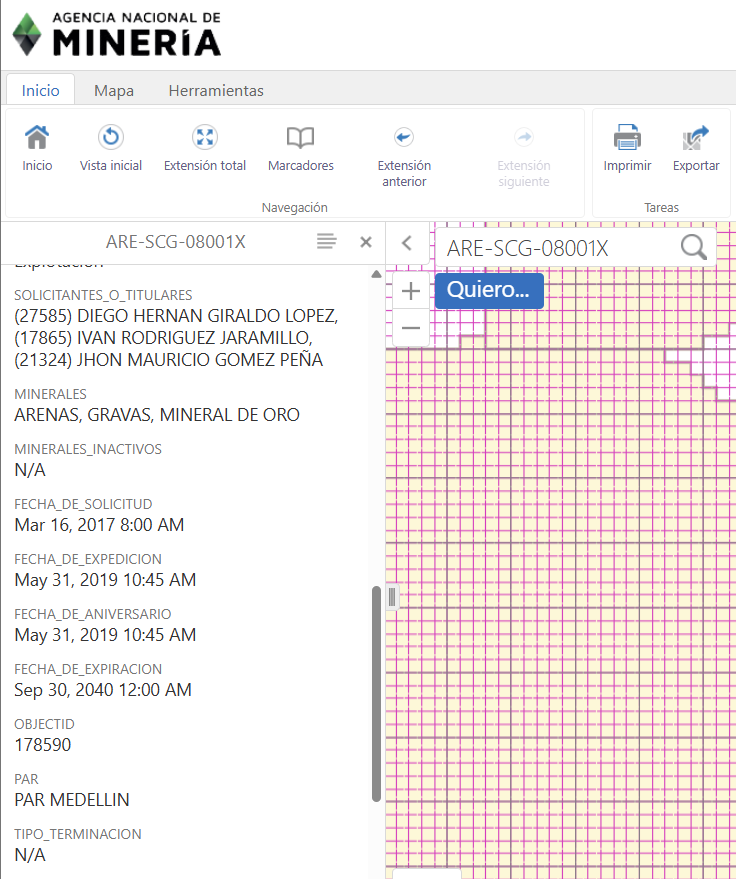 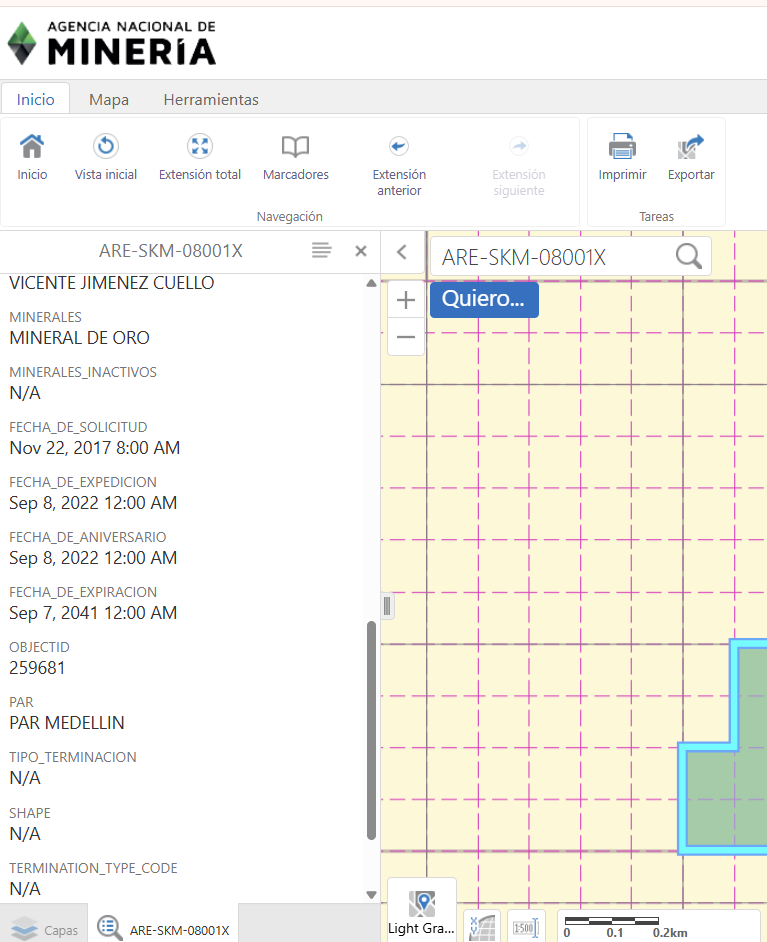

## Calcular área titulada
Como tengo los registros de
1. Fecha de solciitud el título minero
2. Fecha de expiración del título
3. Área que abarca en cada municio

Puedo crear una panel de (area,municipio) tanto de flujo como de acervo para cada mineral

In [27]:
gdf_titulosMineros.head(2)

,CODIGO_EXPEDIENTE,MODALIDAD,TITULO_ESTADO,AREA_HA,CLASIFICACION_MINERIA,ETAPA,SOLICITANTES_O_TITULARES,MINERALES,FECHA_DE_SOLICITUD,FECHA_DE_EXPEDICION,FECHA_DE_ANIVERSARIO,FECHA_DE_EXPIRACION,PUBLICADO_EN_RUCOM,PAR,TITLE_TYPE_CODE,TENURE_STATUS_CODE,MINING_CLASSIFICATION_CODE,TENURE_STAGE_CODE,CENTROID_COORDINATE,TENURE_ID,OBJECTID,MUNICIPIOS,DEPARTAMENTOS,MINERALES_INACTIVOS,TIPO_TERMINACION,TERMINATION_TYPE_CODE,ACTIVE_TENURE_STATUS_IND,ACTIVE_APPLICATION_STATUS_IND,texto_busqueda,categoria_armonizada,geometry
0,ABQ-101,CONTRATO DE CONCESIÓN (D 2655),Activo,39.08,Mediana,Explotación,(61017) CANTERA LA EMILIA SAS,"DIABASA, RECEBO",1999-02-26 10:00:00,2002-03-05 00:00:00,2002-03-05 00:00:00,2033-06-11,Y,PAR CALI,CCD2,A,MED,EXPT,"-76.51667,3.56964",ABQ-101,176246,YUMBO,Valle del Cauca,None,None,None,Y,N,diabasa recebo,Materiales construccion,"POLYGON ((729239.136 886541.659, 729241.1 8871..."
1,AB1-08C,CONTRATO EN VIRTUD DE APORTE,Activo,35.72,Pequeña,Explotación,(29140) LAUREANO GOMEZ,"ANTRACITA, CARBÓN METALÚRGICO, CARBÓN TÉRMICO",1999-02-01 08:00:00,2002-01-24 04:06:39,2002-01-24 04:06:39,2012-01-23,N,PAR NOBSA,CVA,A,PEQ,EXPT,"-72.81173,5.77217",AB1-08C,173771,TÓPAGA,Boyacá,None,None,None,Y,N,antracita carbon metalurgico carbon termico,Carbon,"POLYGON ((1140103.3 1129899.391, 1140706.775 1..."


In [28]:
# Para cada categoría mineral,
# calculo el area que se intersecta con los polígonos de los municipios

# Extraer informaciónde interés
municipios_base = gdf_municipios[['mpio_cdpmp', 'geometry']]
titulos_base = gdf_titulosMineros.copy()

# Hcaer intersección de polígonos
gdf_interseccion_titulosMineros = gpd.overlay(titulos_base, municipios_base, how='intersection')


In [29]:
# Explorar el resultado
print(MSC_SEPARADOR + '\nShape: ', gdf_interseccion_titulosMineros.shape)

print(MSC_SEPARADOR + '\nHead:\n')
print(gdf_interseccion_titulosMineros.head())

print(MSC_SEPARADOR + '\nInfo:\n')
print(gdf_interseccion_titulosMineros.info())

print(MSC_SEPARADOR + '\nCada poligono de titulo minero puede quedar dividido en varios municipios:\n')
display(gdf_interseccion_titulosMineros.groupby('CODIGO_EXPEDIENTE')['mpio_cdpmp'].count().sort_values(ascending=False))


--------------------------------
Shape:  (3742, 32)

--------------------------------
Head:

  CODIGO_EXPEDIENTE                       MODALIDAD TITULO_ESTADO  AREA_HA CLASIFICACION_MINERIA        ETAPA  \
0           ABQ-101  CONTRATO DE CONCESIÓN (D 2655)        Activo    39.08               Mediana  Explotación   
1     ARE-TCG-09531  CONTRATO ESPECIAL DE CONCESIÓN        Activo    75.10               Mediana  Explotación   
2           BCA-081   CONTRATO DE CONCESIÓN (L 685)        Activo    36.65               Pequeña  Explotación   
3           CLB-151   CONTRATO DE CONCESIÓN (L 685)        Activo    27.47               Mediana  Explotación   
4           ECS-131   CONTRATO DE CONCESIÓN (L 685)        Activo    47.86               Mediana  Explotación   

                            SOLICITANTES_O_TITULARES             MINERALES  FECHA_DE_SOLICITUD FECHA_DE_EXPEDICION FECHA_DE_ANIVERSARIO  \
0                      (61017) CANTERA LA EMILIA SAS       DIABASA, RECEBO 1999-02-26 10

CODIGO_EXPEDIENTE
006-85M      14
T13635011    10
070-89       10
L853005       7
L5682005      7
             ..
AGF-092       1
AGM-151       1
AGU-102       1
AHP-111       1
ED3-092       1
Name: mpio_cdpmp, Length: 2769, dtype: int64

In [30]:
# Calcular area de cada polígono
# Como ya estoy en Bogotá-Magnas-Sirgas, los cálculos de area ya salen en m^2
gdf_interseccion_titulosMineros["area_intersectada_m2"] = gdf_interseccion_titulosMineros.geometry.area

# # Calcular el area de cada municipio
# municipios_base["area_municipio_m2"] = municipios_base.geometry.area

# # Anexar cálculo de area municipal a gdf de intersección
# gdf_interseccion_titulosMineros = gdf_interseccion_titulosMineros.merge(
#     municipios_base[["mpio_cdpmp", "area_municipio_m2"]],
#     on="mpio_cdpmp",
#     how="left"
# )

## Calcular Panel de Stock y flujo de area del título minero
La fecha relevante para el área del título minero puede ser por área solicitada o por área expedida

In [31]:
# Los títulos mineros consideran minería ['Pequeña', 'Mediana', 'Grande', 'No aplica']
# La literatura sugiere que la minería 'Grande' puede tener efectos diferentes a las demás
# debido a que conlleva mayor control e inversión social
display(gdf_interseccion_titulosMineros['CLASIFICACION_MINERIA'].value_counts())

# Por eso voy a crear una distinción entre minería "Grande" y las demás
gdf_interseccion_titulosMineros['clasificacion_mineria'] = 'Otras'
mascara = gdf_interseccion_titulosMineros['CLASIFICACION_MINERIA']=='Grande'
gdf_interseccion_titulosMineros.loc[mascara, 'clasificacion_mineria'] = 'Grande'

# Mostrar las dos clasificaciones
display(gdf_interseccion_titulosMineros.groupby(['CLASIFICACION_MINERIA', 'clasificacion_mineria'])
        ['CODIGO_EXPEDIENTE']
        .count().reset_index()
       )

CLASIFICACION_MINERIA
Pequeña      2178
Mediana      1395
Grande         76
No aplica      44
Name: count, dtype: int64

,CLASIFICACION_MINERIA,clasificacion_mineria,CODIGO_EXPEDIENTE
0,Grande,Grande,76
1,Mediana,Otras,1395
2,No aplica,Otras,44
3,Pequeña,Otras,2178


In [32]:

# Crear variable de año
gdf_interseccion_titulosMineros['anno_solicitud'] = gdf_interseccion_titulosMineros['FECHA_DE_SOLICITUD'].dt.year
gdf_interseccion_titulosMineros['anno_expedicion'] = gdf_interseccion_titulosMineros['FECHA_DE_EXPEDICION'].dt.year
gdf_interseccion_titulosMineros['anno_expiracion'] = gdf_interseccion_titulosMineros['FECHA_DE_EXPIRACION'].dt.year


# Crear df con area anual solicitada y expedida por cada Mineral y tipo de minería [grande, pequeña]
area_anual_solicitada = gdf_interseccion_titulosMineros.groupby(
    ['mpio_cdpmp','anno_solicitud', 'clasificacion_mineria', 'categoria_armonizada'])['area_intersectada_m2'].sum().reset_index()
area_anual_expedida = gdf_interseccion_titulosMineros.groupby(
    ['mpio_cdpmp','anno_expedicion', 'clasificacion_mineria', 'categoria_armonizada'])['area_intersectada_m2'].sum().reset_index()
area_anual_expirada = gdf_interseccion_titulosMineros.groupby(
    ['mpio_cdpmp','anno_expiracion', 'clasificacion_mineria', 'categoria_armonizada'])['area_intersectada_m2'].sum().reset_index()

# Arreglar nombre de las variables en cada DF
area_anual_solicitada = area_anual_solicitada.rename(columns=
                                                     {'anno_solicitud':COL_ANNO,
                                                     'area_intersectada_m2':'area_solicitada_m2'})
area_anual_expedida = area_anual_expedida.rename(columns=
                                                 {'anno_expedicion':COL_ANNO,
                                                 'area_intersectada_m2':'area_expedida_m2'})
area_anual_expirada = area_anual_expirada.rename(columns=
                                                 {'anno_expiracion':COL_ANNO,
                                                 'area_intersectada_m2':'area_expirada_m2'})

In [33]:
# Explorar resultados

# mostrar dfs
print(f"\n{'*'*20} Area solicitada")
display(area_anual_solicitada.shape)
display(area_anual_solicitada.head(2))
print(f"\n{'*'*20} Area expedida")
display(area_anual_expedida.shape)
display(area_anual_expedida.head(2))
print(f"\n{'*'*20} Area expirada")
display(area_anual_expirada.head(2))
display(area_anual_expirada.shape)


******************** Area solicitada


(2607, 5)

,mpio_cdpmp,anno,clasificacion_mineria,categoria_armonizada,area_solicitada_m2
0,05001,1985,Otras,Materiales construccion,"400,871.67"
1,05001,1991,Otras,Materiales construccion,"313,470.28"



******************** Area expedida


(2638, 5)

,mpio_cdpmp,anno,clasificacion_mineria,categoria_armonizada,area_expedida_m2
0,05001,1990,Otras,Materiales construccion,"400,871.67"
1,05001,1992,Otras,Materiales construccion,"416,496.52"



******************** Area expirada


,mpio_cdpmp,anno,clasificacion_mineria,categoria_armonizada,area_expirada_m2
0,05001,"2,033.00",Otras,Materiales construccion,"426,773.78"
1,05001,"2,034.00",Otras,Materiales construccion,"610,897.22"


(2782, 5)

## Armar paneles de flujo y stock

In [34]:
# Las observaciones del mismo (categoría mineral armonizada, año, municipio, clasificacion_minera) se suman

df_solicitada = area_anual_solicitada.groupby(
    ['categoria_armonizada', 'mpio_cdpmp', 'anno', 'clasificacion_mineria'], as_index=False)['area_solicitada_m2'].sum()
df_expedida = area_anual_expedida.groupby(
    ['categoria_armonizada', 'mpio_cdpmp', 'anno', 'clasificacion_mineria'], as_index=False)['area_expedida_m2'].sum()
df_expirada = area_anual_expirada.groupby(
    ['categoria_armonizada', 'mpio_cdpmp', 'anno', 'clasificacion_mineria'], as_index=False)['area_expirada_m2'].sum()


# Asegurarse de que el tipo de las variables es el esperado
df_solicitada['anno'] = pd.to_numeric(df_solicitada['anno'], errors='coerce').astype('Int64')
df_solicitada['area_solicitada_m2'] = pd.to_numeric(df_solicitada['area_solicitada_m2'], errors='coerce').fillna(0)

df_expedida['anno'] = pd.to_numeric(df_expedida['anno'], errors='coerce').astype('Int64')
df_expedida['area_expedida_m2'] = pd.to_numeric(df_expedida['area_expedida_m2'], errors='coerce').fillna(0)

df_expirada['anno'] = pd.to_numeric(df_expirada['anno'], errors='coerce').astype('Int64')
df_expirada['area_expirada_m2'] = pd.to_numeric(df_expirada['area_expirada_m2'], errors='coerce').fillna(0)

# Encontrar el intervalo de tiempo
anio_min = int(min([df_solicitada['anno'].min(), df_expedida['anno'].min(), df_expirada['anno'].min()]))
anio_max = int(min([df_solicitada['anno'].max(), df_expedida['anno'].max(), df_expirada['anno'].max()]))

In [35]:
# Encontrar el dominio de cada variable para crear un panel balanceado
municipios = df_solicitada['mpio_cdpmp'].drop_duplicates().sort_values()
tipos = df_solicitada['clasificacion_mineria'].drop_duplicates().sort_values()
anios = pd.Index(range(anio_min, anio_max + 1), name='anno')
categorias_armonizadas = df_solicitada['categoria_armonizada'].drop_duplicates().sort_values()

In [36]:
# Crear panel base
panel_base = (
    pd.MultiIndex.from_product(
        [categorias_armonizadas, municipios, anios, tipos],
        names=['categoria_armonizada', 'mpio_cdpmp', 'anno', 'clasificacion_mineria']
    )
    .to_frame(index=False)
)

# Incorporar observaciones al panel base
panel_flujo = (
    panel_base
    .merge(df_solicitada, on=['categoria_armonizada', 'mpio_cdpmp', 'anno', 'clasificacion_mineria'], how='left')
)

panel_flujo = (
    panel_flujo
    .merge(df_expedida, on=['categoria_armonizada', 'mpio_cdpmp', 'anno', 'clasificacion_mineria'], how='left')
)

panel_flujo = (
    panel_flujo
    .merge(df_expirada, on=['categoria_armonizada', 'mpio_cdpmp', 'anno', 'clasificacion_mineria'], how='left')
)


# En los años en que no hay registros, el flujo es 0
panel_flujo['area_solicitada_m2'] = panel_flujo['area_solicitada_m2'].fillna(0)
panel_flujo['area_expedida_m2'] = panel_flujo['area_expedida_m2'].fillna(0)
panel_flujo['area_expirada_m2'] = panel_flujo['area_expirada_m2'].fillna(0)

# calcular area titulada
# Como cada fila del DF corresponde a una observación de mpio, año, categoria, tipo
# se puede hacer el siguiente cálculo
panel_flujo['area_titulada_m2'] = panel_flujo['area_expedida_m2'] - panel_flujo['area_expirada_m2']

In [37]:
# Crear panel de stock a partir del panel de flujo
panel_stock = panel_flujo.copy()

# Calcular el stock de area solicitada y area titulada de cada (categoria mineral, municipio, año, tipo de minería)
panel_stock[['area_solicitada_stock_m2', 'area_titulada_stock_m2']] = (
    panel_stock
    .sort_values(['categoria_armonizada','mpio_cdpmp', 'clasificacion_mineria', 'anno'])
    .groupby(['categoria_armonizada','mpio_cdpmp', 'clasificacion_mineria'])[['area_solicitada_m2', 'area_titulada_m2']]
    .cumsum() # Suma acumulada con el panel organizado por año
)

## Conservar solo variables relevantes

In [38]:
# Depurar la información que se conserva
panel_flujo = panel_flujo[
    [
        'categoria_armonizada', 'mpio_cdpmp', COL_ANNO, 'clasificacion_mineria', 'area_solicitada_m2', 'area_titulada_m2'
    ]
]

panel_stock = panel_stock[
    [
        'categoria_armonizada', 'mpio_cdpmp', COL_ANNO, 'clasificacion_mineria', 'area_solicitada_stock_m2', 'area_titulada_stock_m2'
    ]
]

In [39]:
# Mostrar estructura de los datos
print(MSC_SEPARADOR, '\nPanel de Flujo')
display(panel_flujo.head())

print(MSC_SEPARADOR, '\nPanel de Stock')
display(panel_stock.head())


-------------------------------- 
Panel de Flujo


,categoria_armonizada,mpio_cdpmp,anno,clasificacion_mineria,area_solicitada_m2,area_titulada_m2
0,Carbon,05001,1968,Grande,0.00,0.00
1,Carbon,05001,1968,Otras,0.00,0.00
2,Carbon,05001,1969,Grande,0.00,0.00
3,Carbon,05001,1969,Otras,0.00,0.00
4,Carbon,05001,1970,Grande,0.00,0.00



-------------------------------- 
Panel de Stock


,categoria_armonizada,mpio_cdpmp,anno,clasificacion_mineria,area_solicitada_stock_m2,area_titulada_stock_m2
0,Carbon,05001,1968,Grande,0.00,0.00
1,Carbon,05001,1968,Otras,0.00,0.00
2,Carbon,05001,1969,Grande,0.00,0.00
3,Carbon,05001,1969,Otras,0.00,0.00
4,Carbon,05001,1970,Grande,0.00,0.00


## Estructurar archivo de salida
Convierto los datos a la estructura convenida para todas las bases de datos

In [40]:
# Revisar estructura de los dataframes procesados para ahcer un análogo
potencialMineral_panel.head(4)

,codigo_dane_municipio,variable_sujeto,variable_medicion,valor,anno,clasificacion_econometria,nombre_variable,variable_detalle,variable_descripcion
0,05001,Gemas,area_potencial_m2,"225,867,083.63",0,Instrumento,,formación geológica,Zonas de potencial geologico. Mineral: Gemas. ...
1,05001,Materiales construccion,area_potencial_m2,"293,906,510.88",0,Instrumento,,formación geológica,Zonas de potencial geologico. Mineral: Materia...
2,05001,Metales base,area_potencial_m2,"69,882,546.73",0,Instrumento,,formación geológica,Zonas de potencial geologico. Mineral: Metales...
3,05001,Niquel,area_potencial_m2,"154,283,471.12",0,Instrumento,,formación geológica,Zonas de potencial geologico. Mineral: Niquel....


In [41]:
# Convertir los datos a estructura convenida
titulosMineros_panel_flujo_estructurado = panel_flujo.melt(
    id_vars=['categoria_armonizada', 'mpio_cdpmp', 'anno', 'clasificacion_mineria'],
    value_vars=['area_solicitada_m2', 'area_titulada_m2'],
    var_name=COL_VARIABLE_MEDICION,
    value_name=COL_VALOR
)

titulosMineros_panel_stock_estructurado = panel_stock.melt(
    id_vars=['categoria_armonizada', 'mpio_cdpmp', 'anno', 'clasificacion_mineria'],
    value_vars=['area_solicitada_stock_m2', 'area_titulada_stock_m2'],
    var_name=COL_VARIABLE_MEDICION,
    value_name=COL_VALOR
)

# Asignar nombres en el estándar definido
titulosMineros_panel_flujo_estructurado = titulosMineros_panel_flujo_estructurado.rename(
    columns={
        'mpio_cdpmp': COL_ID_MUNICIPIO,
        'categoria_armonizada': COL_VARIABLE_SUJETO
    }
)

titulosMineros_panel_stock_estructurado = titulosMineros_panel_stock_estructurado.rename(
    columns={
        'mpio_cdpmp': COL_ID_MUNICIPIO,
        'categoria_armonizada': COL_VARIABLE_SUJETO
    }
)

# En el panel de flujo, hacer explicito que la variable es flujo
# En el de stock no es necesario porque ya estaba explícito
titulosMineros_panel_flujo_estructurado[COL_VARIABLE_MEDICION] = titulosMineros_panel_flujo_estructurado[COL_VARIABLE_MEDICION].str.replace('_m2', '_flujo_m2')

# Completar información del panel
titulosMineros_panel_flujo_estructurado[COL_CLASIFICACION_ECONOMETRIA] = 'Sin definir. Posible X' # Esta variable se piensa usar como instrumento
titulosMineros_panel_flujo_estructurado[COL_NOMBRE_DE_VARIABLE] = ''
titulosMineros_panel_flujo_estructurado[COL_VARIABLE_DETALLE] = 'Tamaño Mineria ' + titulosMineros_panel_flujo_estructurado['clasificacion_mineria']
titulosMineros_panel_flujo_estructurado[COL_VARIABLE_DESCRIPCION] = (
    'Titulos mineros. ' +
    'Mineral: ' + titulosMineros_panel_flujo_estructurado[COL_VARIABLE_SUJETO]
    + '. Medición: ' + titulosMineros_panel_flujo_estructurado[COL_VARIABLE_MEDICION] 
    + '. Desagregación: ' + titulosMineros_panel_flujo_estructurado[COL_VARIABLE_DETALLE] 
)

# Completar información del panel
titulosMineros_panel_stock_estructurado[COL_CLASIFICACION_ECONOMETRIA] = 'Sin definir. Posible X' # Esta variable se piensa usar como instrumento
titulosMineros_panel_stock_estructurado[COL_NOMBRE_DE_VARIABLE] = ''
titulosMineros_panel_stock_estructurado[COL_VARIABLE_DETALLE] = 'Tamaño Mineria ' + titulosMineros_panel_stock_estructurado['clasificacion_mineria']
titulosMineros_panel_stock_estructurado[COL_VARIABLE_DESCRIPCION] = (
    'Titulos mineros. ' +
    'Mineral: ' + titulosMineros_panel_stock_estructurado[COL_VARIABLE_SUJETO]
    + '. Medición: ' + titulosMineros_panel_stock_estructurado[COL_VARIABLE_MEDICION] 
    + '. Desagregación: ' + titulosMineros_panel_stock_estructurado[COL_VARIABLE_DETALLE] 
)

# Mostrar como quedaron los paneles
print(MSC_SEPARADOR, "Panel de flujo")
display(titulosMineros_panel_flujo_estructurado[ORDEN_DF].head(2))

print(MSC_SEPARADOR, "Panel de Stock")
display(titulosMineros_panel_stock_estructurado[ORDEN_DF].head(2))


-------------------------------- Panel de flujo


,codigo_dane_municipio,anno,nombre_variable,variable_sujeto,variable_medicion,variable_detalle,variable_descripcion,valor,clasificacion_econometria
0,05001,1968,,Carbon,area_solicitada_flujo_m2,Tamaño Mineria Grande,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X
1,05001,1968,,Carbon,area_solicitada_flujo_m2,Tamaño Mineria Otras,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X



-------------------------------- Panel de Stock


,codigo_dane_municipio,anno,nombre_variable,variable_sujeto,variable_medicion,variable_detalle,variable_descripcion,valor,clasificacion_econometria
0,05001,1968,,Carbon,area_solicitada_stock_m2,Tamaño Mineria Grande,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X
1,05001,1968,,Carbon,area_solicitada_stock_m2,Tamaño Mineria Otras,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X


In [98]:
# Asignar nombresde variables ---- panel de flujo

# Asignar el nombre de las variables
print(MSC_SEPARADOR, 'Medicion (Unicos)')
display(titulosMineros_panel_flujo_estructurado[COL_VARIABLE_MEDICION].unique())
print(MSC_SEPARADOR, 'Detalle (Unicos)')
display(titulosMineros_panel_flujo_estructurado[COL_VARIABLE_DETALLE].unique())

# Generar partes del nombre de la variable
concepto = 'tituMine_'
sujeto = titulosMineros_panel_flujo_estructurado[COL_VARIABLE_SUJETO].map(DICCIONARIO_ABREVIACIONES_MINERALES) + '_'
medicion = titulosMineros_panel_flujo_estructurado[COL_VARIABLE_MEDICION].map({'area_solicitada_flujo_m2':'AreaSo', 'area_titulada_flujo_m2':'AreaTi'}) + '_'
detalle = titulosMineros_panel_flujo_estructurado[COL_VARIABLE_DETALLE].map({'Tamaño Mineria Grande':'tGrn', 'Tamaño Mineria Otras':'tOtr'}) + '_'
unidades = 'm2Fx'

# Armar el nombre de la variable
titulosMineros_panel_flujo_estructurado[COL_NOMBRE_DE_VARIABLE] = concepto + sujeto + medicion + detalle + unidades

print(MSC_SEPARADOR, 'Head')
display(titulosMineros_panel_flujo_estructurado[ORDEN_DF].head())

print(MSC_SEPARADOR, 'nombres únicos')
display(titulosMineros_panel_flujo_estructurado[COL_NOMBRE_DE_VARIABLE].unique())

print("El nombre de variable más largo no puede ser superior a 32 caracteres")
display(titulosMineros_panel_flujo_estructurado[COL_NOMBRE_DE_VARIABLE].str.len().max())


-------------------------------- Medicion (Unicos)


array(['area_solicitada_flujo_m2', 'area_titulada_flujo_m2'], dtype=object)


-------------------------------- Detalle (Unicos)


array(['Tamaño Mineria Grande', 'Tamaño Mineria Otras'], dtype=object)


-------------------------------- Head


,codigo_dane_municipio,anno,nombre_variable,variable_sujeto,variable_medicion,variable_detalle,variable_descripcion,valor,clasificacion_econometria
0,05001,1968,tituMine_carbon_AreaSo_tGrn_m2Fx,Carbon,area_solicitada_flujo_m2,Tamaño Mineria Grande,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X
1,05001,1968,tituMine_carbon_AreaSo_tOtr_m2Fx,Carbon,area_solicitada_flujo_m2,Tamaño Mineria Otras,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X
2,05001,1969,tituMine_carbon_AreaSo_tGrn_m2Fx,Carbon,area_solicitada_flujo_m2,Tamaño Mineria Grande,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X
3,05001,1969,tituMine_carbon_AreaSo_tOtr_m2Fx,Carbon,area_solicitada_flujo_m2,Tamaño Mineria Otras,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X
4,05001,1970,tituMine_carbon_AreaSo_tGrn_m2Fx,Carbon,area_solicitada_flujo_m2,Tamaño Mineria Grande,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X



-------------------------------- nombres únicos


array(['tituMine_carbon_AreaSo_tGrn_m2Fx',
       'tituMine_carbon_AreaSo_tOtr_m2Fx',
       'tituMine_cobre_AreaSo_tGrn_m2Fx',
       'tituMine_cobre_AreaSo_tOtr_m2Fx',
       'tituMine_fertlz_AreaSo_tGrn_m2Fx',
       'tituMine_fertlz_AreaSo_tOtr_m2Fx',
       'tituMine_gemas_AreaSo_tGrn_m2Fx',
       'tituMine_gemas_AreaSo_tOtr_m2Fx',
       'tituMine_mConst_AreaSo_tGrn_m2Fx',
       'tituMine_mConst_AreaSo_tOtr_m2Fx',
       'tituMine_metBas_AreaSo_tGrn_m2Fx',
       'tituMine_metBas_AreaSo_tOtr_m2Fx',
       'tituMine_mIndus_AreaSo_tGrn_m2Fx',
       'tituMine_mIndus_AreaSo_tOtr_m2Fx',
       'tituMine_niquel_AreaSo_tGrn_m2Fx',
       'tituMine_niquel_AreaSo_tOtr_m2Fx',
       'tituMine_oro_AreaSo_tGrn_m2Fx', 'tituMine_oro_AreaSo_tOtr_m2Fx',
       'tituMine_otros_AreaSo_tGrn_m2Fx',
       'tituMine_otros_AreaSo_tOtr_m2Fx',
       'tituMine_carbon_AreaTi_tGrn_m2Fx',
       'tituMine_carbon_AreaTi_tOtr_m2Fx',
       'tituMine_cobre_AreaTi_tGrn_m2Fx',
       'tituMine_cobre_AreaTi_t

El nombre de variable más largo no puede ser superior a 32 caracteres


32

In [89]:
# Asignar nombresde variables ---- panel de Stock

# Asignar el nombre de las variables
print(MSC_SEPARADOR, 'Medicion (Unicos)')
display(titulosMineros_panel_stock_estructurado[COL_VARIABLE_MEDICION].unique())
print(MSC_SEPARADOR, 'Detalle (Unicos)')
display(titulosMineros_panel_stock_estructurado[COL_VARIABLE_DETALLE].unique())


-------------------------------- Medicion (Unicos)


array(['area_solicitada_stock_m2', 'area_titulada_stock_m2'], dtype=object)


-------------------------------- Detalle (Unicos)


array(['Tamaño Mineria Grande', 'Tamaño Mineria Otras'], dtype=object)

In [99]:
# Generar partes del nombre de la variable
concepto = 'tituMine_'
sujeto = titulosMineros_panel_stock_estructurado[COL_VARIABLE_SUJETO].map(DICCIONARIO_ABREVIACIONES_MINERALES) + '_'
medicion = titulosMineros_panel_stock_estructurado[COL_VARIABLE_MEDICION].map({'area_solicitada_stock_m2':'AreaSo', 'area_titulada_stock_m2':'AreaTi'}) + '_'
detalle = titulosMineros_panel_stock_estructurado[COL_VARIABLE_DETALLE].map({'Tamaño Mineria Grande':'tGrn', 'Tamaño Mineria Otras':'tOtr'}) + '_'
unidades = 'm2Sk'

# Armar el nombre de la variable
titulosMineros_panel_stock_estructurado[COL_NOMBRE_DE_VARIABLE] = concepto + sujeto + medicion + detalle + unidades

print(MSC_SEPARADOR, 'Head')
display(titulosMineros_panel_stock_estructurado[ORDEN_DF].head())

print(MSC_SEPARADOR, 'nombres únicos')
display(titulosMineros_panel_stock_estructurado[COL_NOMBRE_DE_VARIABLE].unique())

print("El nombre de variable más largo no puede ser superior a 32 caracteres")
display(titulosMineros_panel_stock_estructurado[COL_NOMBRE_DE_VARIABLE].str.len().max())


-------------------------------- Head


,codigo_dane_municipio,anno,nombre_variable,variable_sujeto,variable_medicion,variable_detalle,variable_descripcion,valor,clasificacion_econometria
0,05001,1968,tituMine_carbon_AreaSo_tGrn_m2Sk,Carbon,area_solicitada_stock_m2,Tamaño Mineria Grande,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X
1,05001,1968,tituMine_carbon_AreaSo_tOtr_m2Sk,Carbon,area_solicitada_stock_m2,Tamaño Mineria Otras,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X
2,05001,1969,tituMine_carbon_AreaSo_tGrn_m2Sk,Carbon,area_solicitada_stock_m2,Tamaño Mineria Grande,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X
3,05001,1969,tituMine_carbon_AreaSo_tOtr_m2Sk,Carbon,area_solicitada_stock_m2,Tamaño Mineria Otras,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X
4,05001,1970,tituMine_carbon_AreaSo_tGrn_m2Sk,Carbon,area_solicitada_stock_m2,Tamaño Mineria Grande,Titulos mineros. Mineral: Carbon. Medición: ar...,0.00,Sin definir. Posible X



-------------------------------- nombres únicos


array(['tituMine_carbon_AreaSo_tGrn_m2Sk',
       'tituMine_carbon_AreaSo_tOtr_m2Sk',
       'tituMine_cobre_AreaSo_tGrn_m2Sk',
       'tituMine_cobre_AreaSo_tOtr_m2Sk',
       'tituMine_fertlz_AreaSo_tGrn_m2Sk',
       'tituMine_fertlz_AreaSo_tOtr_m2Sk',
       'tituMine_gemas_AreaSo_tGrn_m2Sk',
       'tituMine_gemas_AreaSo_tOtr_m2Sk',
       'tituMine_mConst_AreaSo_tGrn_m2Sk',
       'tituMine_mConst_AreaSo_tOtr_m2Sk',
       'tituMine_metBas_AreaSo_tGrn_m2Sk',
       'tituMine_metBas_AreaSo_tOtr_m2Sk',
       'tituMine_mIndus_AreaSo_tGrn_m2Sk',
       'tituMine_mIndus_AreaSo_tOtr_m2Sk',
       'tituMine_niquel_AreaSo_tGrn_m2Sk',
       'tituMine_niquel_AreaSo_tOtr_m2Sk',
       'tituMine_oro_AreaSo_tGrn_m2Sk', 'tituMine_oro_AreaSo_tOtr_m2Sk',
       'tituMine_otros_AreaSo_tGrn_m2Sk',
       'tituMine_otros_AreaSo_tOtr_m2Sk',
       'tituMine_carbon_AreaTi_tGrn_m2Sk',
       'tituMine_carbon_AreaTi_tOtr_m2Sk',
       'tituMine_cobre_AreaTi_tGrn_m2Sk',
       'tituMine_cobre_AreaTi_t

El nombre de variable más largo no puede ser superior a 32 caracteres


32

# Organizar DF de salida

Los dataframes relevantes son

Sección | DFs de salida | Descripción corta|
---|---|---
6. Cálculos de Área | ```potencialMineral_panel``` | para (municipio, año, mineral) calculo el **area con potencial geológico** en m2 y como porcentaje del area municipal|
7. Cálculos de distancia: Aluvión y potencial | ```instrumentos_distancia_panel``` | para (municipio, año, mineral) calculo la **distancia** al potencial geológico (zonas de potencial, aluvión)|
8. Títulos mineros | ```titulosMineros_panel_flujo_estructurado```,  ```titulosMineros_panel_stock_estructurado```| para (municipio, año, mineral), calculo **(flujo, stock)** de área (titulada, solicitada)|

In [112]:
# Concatenar DFs de salida
dfOutput_indicadoresGeoespacialesMinerales = pd.concat(
    [
        potencialMineral_panel,
        instrumentos_distancia_panel,
        titulosMineros_panel_flujo_estructurado,
        titulosMineros_panel_stock_estructurado
    ])

# Revisar que no haya nombres de variables repetidos:
N_unido = dfOutput_indicadoresGeoespacialesMinerales[COL_NOMBRE_DE_VARIABLE].nunique()
N_sumado = (potencialMineral_panel[COL_NOMBRE_DE_VARIABLE].nunique() + 
            instrumentos_distancia_panel[COL_NOMBRE_DE_VARIABLE].nunique() + 
            titulosMineros_panel_flujo_estructurado[COL_NOMBRE_DE_VARIABLE].nunique() + 
            titulosMineros_panel_stock_estructurado[COL_NOMBRE_DE_VARIABLE].nunique())
print(MSC_SEPARADOR, f'Ambos conteos de nombres unicos debe ser iguales\nUnido: {N_unido}\nSumado: {N_sumado}')

# Eliminar observaciones de NAN en la columna de "valor"
dfOutput_indicadoresGeoespacialesMinerales = dfOutput_indicadoresGeoespacialesMinerales.dropna(subset=COL_VALOR)

# Conservar solo las columnas convenidas para la estructura del Panel
dfOutput_indicadoresGeoespacialesMinerales = dfOutput_indicadoresGeoespacialesMinerales[ORDEN_DF]

# Revisar que ningun nombre de variable sea mas largo que 32 caracteres
print(MSC_SEPARADOR, "Ningun nombre de variable puede ser mas largo que 32 caracteres")
display(dfOutput_indicadoresGeoespacialesMinerales[COL_NOMBRE_DE_VARIABLE].str.len().max())


-------------------------------- Ambos conteos de nombres unicos debe ser iguales
Unido: 120
Sumado: 120

-------------------------------- Ningun nombre de variable puede ser mas largo que 32 caracteres


32

In [118]:
# Dar forma al Dataframe para leerlo en STATA
df_salida_STATA = dfOutput_indicadoresGeoespacialesMinerales.pivot(
        index=[COL_ANNO, COL_ID_MUNICIPIO],
        columns=COL_NOMBRE_DE_VARIABLE,
        values=COL_VALOR
    ).reset_index().rename_axis(columns=None)

## Explorar estructura del DF generado

In [113]:
print(MSC_SEPARADOR, 'Head')
display(dfOutput_indicadoresGeoespacialesMinerales.head())

print(MSC_SEPARADOR, 'Info')
display(dfOutput_indicadoresGeoespacialesMinerales.info())

print(MSC_SEPARADOR, 'Variables registradas')



-------------------------------- Head


,codigo_dane_municipio,anno,nombre_variable,variable_sujeto,variable_medicion,variable_detalle,variable_descripcion,valor,clasificacion_econometria
0,05001,0,poteMine_gemas_area_roca_m2,Gemas,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Gemas. ...,"225,867,083.63",Instrumento
1,05001,0,poteMine_mConst_area_roca_m2,Materiales construccion,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Materia...,"293,906,510.88",Instrumento
2,05001,0,poteMine_metBas_area_roca_m2,Metales base,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Metales...,"69,882,546.73",Instrumento
3,05001,0,poteMine_niquel_area_roca_m2,Niquel,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Niquel....,"154,283,471.12",Instrumento
4,05002,0,poteMine_cobre_area_roca_m2,Cobre,area_potencial_m2,formación geológica,Zonas de potencial geologico. Mineral: Cobre. ...,"216,183,066.50",Instrumento



-------------------------------- Info
<class 'pandas.core.frame.DataFrame'>
Index: 2945060 entries, 0 to 1462999
Data columns (total 9 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   codigo_dane_municipio      object 
 1   anno                       int64  
 2   nombre_variable            object 
 3   variable_sujeto            object 
 4   variable_medicion          object 
 5   variable_detalle           object 
 6   variable_descripcion       object 
 7   valor                      float64
 8   clasificacion_econometria  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 224.7+ MB


None


-------------------------------- Variables registradas


In [114]:
dfOutput_indicadoresGeoespacialesMinerales.groupby([COL_VARIABLE_DESCRIPCION])[COL_ID_MUNICIPIO].count().reset_index()

,variable_descripcion,codigo_dane_municipio
0,Distancia a recursos minerales. Mineral: Cobre...,1122
1,Distancia a recursos minerales. Mineral: Ferti...,1122
2,Distancia a recursos minerales. Mineral: Gemas...,1122
3,Distancia a recursos minerales. Mineral: Mater...,1122
4,Distancia a recursos minerales. Mineral: Metal...,1122
...,...,...
107,Zonas de potencial geologico. Mineral: Oro. Me...,373
108,Zonas de potencial geologico. Mineral: Otros m...,81
109,Zonas de potencial geologico. Mineral: Otros m...,81
110,Zonas de potencial geologico. Mineral: Otros. ...,283


In [115]:
# Con la descripción, debería entender lo que es cada variable
list(dfOutput_indicadoresGeoespacialesMinerales[COL_VARIABLE_DESCRIPCION].unique())

['Zonas de potencial geologico. Mineral: Gemas. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
 'Zonas de potencial geologico. Mineral: Materiales construccion. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
 'Zonas de potencial geologico. Mineral: Metales base. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
 'Zonas de potencial geologico. Mineral: Niquel. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
 'Zonas de potencial geologico. Mineral: Cobre. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
 'Zonas de potencial geologico. Mineral: Oro. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
 'Zonas de potencial geologico. Mineral: Otros. Medición: area_potencial_m2. Desagregación: Minería de formación geológica',
 'Zonas de potencial geologico. Mineral: Minerales industriales. Medición: area_potencial_m2. Desagre

## Exportar parquet

In [116]:
# Exportar archivo de salida
dfOutput_indicadoresGeoespacialesMinerales.to_parquet(
    DATA/'intermediate/e2100_panel_IndicadoresGeoEspaciales_Minerales.parquet')

## Exportar STATA

In [123]:
# Exportar a STATA
df_stata = df_salida_STATA.copy()

# En este caso, los strings quedaron en el tipo básico de string y no hubo problemas
columnas_string = df_stata.select_dtypes(include="string").columns

df_stata[columnas_string] = (
    df_stata[columnas_string]
    .astype(object)
    .where(df_stata[columnas_string].notna(), None)
)

df_salida_STATA.to_stata(DATA/'intermediate/e2100_panel_IndicadoresGeoEspaciales_Minerales.dta')

In [126]:
df_stata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37697 entries, 0 to 37696
Columns: 114 entries, anno to tituMine_otros_AreaTi_tOtr_m2Sk
dtypes: float64(112), int64(1), object(1)
memory usage: 32.8+ MB
